# **Task 1 - Data Import and Dataset Merging**

In [2]:
# 1.1 Import required libraries

! pip install pandas numpy

import pandas as pd
import numpy as np


In [3]:
# 1.2 Load Dataset 1 & 2

loan_data_1 = pd.read_csv('/content/Loan_Approval_Data_Set_1.csv')
loan_data_2 = pd.read_csv('/content/Loan_Approval_Data_Set_2.csv')

In [4]:
# 1.3 Display Head

print("Dataset 1 Preview")
print(loan_data_1.head())

print("\nDataset 2 Preview")
print(loan_data_2.head())

Dataset 1 Preview
     ID ApplicationDate  AnnualIncome EmploymentStatus  Experience  \
0  A001      01-01-2018         39948         Employed          22   
1  A002      02-01-2018         39709         Employed          15   
2  A003      03-01-2018         40724         Employed          26   
3  A004      04-01-2018         69084         Employed          34   
4  A005      05-01-2018        103264         Employed          17   

   LoanDuration  NumberOfDependents  MonthlyDebtPayments  \
0            48                   2                  183   
1            48                   1                  496   
2            36                   2                  902   
3            96                   1                  755   
4            36                   1                  274   

   NumberOfOpenCreditLines  BankruptcyHistory  PreviousLoanDefaults  \
0                        1                  0                     0   
1                        5                  0             

In [5]:
# 1.4 Convert Risk Score to numeric

loan_data_2['RiskScore'] = (
    loan_data_2['RiskScore']
    .replace('XX', np.nan)
)

loan_data_2['RiskScore'] = pd.to_numeric(
    loan_data_2['RiskScore'],
    errors='coerce'
)

In [6]:
# 1.5 Check unique IDs

print("Unique IDs in Dataset 1:",
      loan_data_1['ID'].nunique())

print("Unique IDs in Dataset 2:",
      loan_data_2['ID'].nunique())

Unique IDs in Dataset 1: 20000
Unique IDs in Dataset 2: 20000


In [7]:
# 1.6 Merge datasets

loan_dataset = pd.merge(
    loan_data_1,
    loan_data_2,
    on='ID',
    how='inner',
    suffixes=('_financial', '_demographic')
)

In [8]:
# 1.7 Preview merged dataset

loan_dataset.head()

,ID,ApplicationDate_financial,AnnualIncome,EmploymentStatus,Experience_financial,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,...,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,...,Own,35.40,2,Home,29,7632,146111,11,22.75,49.0
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,...,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,NaN
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,...,Rent,13.70,0,Education,20,886,25176,6,21.25,NaN
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,...,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54.0
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,...,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36.0


# **Task 2(a) Fundamental Data Understanding**

In [9]:
# 2(a).1 Dataset Shape

print("Rows and Columns")
print(loan_dataset.shape)

Rows and Columns
(20000, 33)


In [10]:
# 2(a).2 Dataset Information

print("\nDataset Information")
loan_dataset.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           20000 non-null  object 
 1   ApplicationDate_financial    20000 non-null  object 
 2   AnnualIncome                 20000 non-null  int64  
 3   EmploymentStatus             20000 non-null  object 
 4   Experience_financial         20000 non-null  int64  
 5   LoanDuration                 20000 non-null  int64  
 6   NumberOfDependents           20000 non-null  int64  
 7   MonthlyDebtPayments          20000 non-null  int64  
 8   NumberOfOpenCreditLines      20000 non-null  int64  
 9   BankruptcyHistory            20000 non-null  int64  
 10  PreviousLoanDefaults         20000 non-null  int64  
 11  LengthOfCreditHistory        20000 non-null  int64  
 12  CheckingAccountBalance       20000 non-null  int64  


In [11]:
# 2(a).3 Duplicate Records check

print("Duplicate Records:",
      loan_dataset.duplicated().sum())

Duplicate Records: 0


In [12]:
# 2(a).4 Duplicate Columns check

valid_rows = loan_dataset['Experience_demographic'].notna()

matches = (
    loan_dataset.loc[valid_rows, 'Experience_financial']
    ==
    loan_dataset.loc[valid_rows, 'Experience_demographic']
).sum()

total = valid_rows.sum()

print("Matches:", matches)
print("Total Compared:", total)
print("Match Percentage:", round(matches/total*100, 2), "%")

Matches: 19334
Total Compared: 19334
Match Percentage: 100.0 %


In [13]:
# 2(a).5 Missing values

print("Missing Values:")
print(loan_dataset.isnull().sum())

Missing Values:
ID                                0
ApplicationDate_financial         0
AnnualIncome                      0
EmploymentStatus                  0
Experience_financial              0
LoanDuration                      0
NumberOfDependents                0
MonthlyDebtPayments               0
NumberOfOpenCreditLines           0
BankruptcyHistory                 0
PreviousLoanDefaults              0
LengthOfCreditHistory             0
CheckingAccountBalance            0
TotalLiabilities                  0
NetWorth                          0
LoanApproved                      0
ApplicationDate_demographic       0
Age                               0
CreditScore                       0
EducationLevel                    0
Experience_demographic          666
LoanAmount                        0
MaritalStatus                    15
HomeOwnershipStatus               0
CreditCardUtilizationRate         0
NumberOfCreditInquiries           0
LoanPurpose                       0
PaymentHisto

In [14]:
# 2(a).6 Missing Value Strategy For RiskScore

loan_dataset['RiskScore'].fillna(
    loan_dataset['RiskScore'].median(),
    inplace=True
)

/tmp/ipykernel_1267/2210656176.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_dataset['RiskScore'].fillna(


In [15]:
# 2(a).7 Missing Value Strategy For MaritalStatus

loan_dataset['MaritalStatus'].fillna(
    loan_dataset['MaritalStatus'].mode()[0],
    inplace=True
)

/tmp/ipykernel_1267/3545244995.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_dataset['MaritalStatus'].fillna(


In [16]:
# 2(a).8 Missing Value Strategy For Experience

loan_dataset.drop(
    columns=['Experience_demographic'],
    inplace=True
)

loan_dataset.rename(
    columns={'Experience_financial': 'Experience'},
    inplace=True
)

In [17]:
# 2(a).9 Statistical Summary

loan_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
AnnualIncome,20000.0,59161.473550,40350.845168,15000.00,31679.00,48566.00,74391.00,485341.00
Experience,20000.0,17.522750,11.316836,0.00,9.00,17.00,25.00,61.00
LoanDuration,20000.0,54.057000,24.664857,12.00,36.00,48.00,72.00,120.00
NumberOfDependents,20000.0,1.517300,1.386325,0.00,0.00,1.00,2.00,5.00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.00,286.00,402.00,564.00,2919.00
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.00,2.00,3.00,4.00,13.00
BankruptcyHistory,20000.0,0.052400,0.222838,0.00,0.00,0.00,0.00,1.00
PreviousLoanDefaults,20000.0,0.100050,0.300074,0.00,0.00,0.00,0.00,1.00
LengthOfCreditHistory,20000.0,14.957300,8.371552,1.00,8.00,15.00,22.00,29.00
CheckingAccountBalance,20000.0,1782.555100,2245.378812,24.00,551.00,1116.00,2126.00,52572.00


# **Task 2(b) Data Preprocessing**

In [18]:
# 2(b).1 Duplicate Checking
print(
    "Duplicate Records:",
    loan_dataset.duplicated().sum()
)

Duplicate Records: 0


In [19]:
# 2(b).2 Feature Engineering i - (Monthly Income)

loan_dataset['MonthlyIncome'] = (
    loan_dataset['AnnualIncome'] / 12
)

In [20]:
# 2(b).3 Feature Engineering ii - (Monthly Loan Payment)

loan_dataset['MonthlyLoanPayment'] = (
    loan_dataset['LoanAmount']
    /
    loan_dataset['LoanDuration']
)

In [21]:
# 2(b).4 Feature Engineering iii - (Debt To Income Ratio)

loan_dataset['TotalDebtToIncomeRatio'] = (
    (
        loan_dataset['MonthlyLoanPayment']
        +
        loan_dataset['MonthlyDebtPayments']
    )
    *
    100
    /
    loan_dataset['MonthlyIncome']
)

In [22]:
# 2(b).5 Verify New Features

loan_dataset[
    [
        'MonthlyIncome',
        'MonthlyLoanPayment',
        'TotalDebtToIncomeRatio'
    ]
].head()

,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,3329.000000,274.000000,13.727846
1,3309.083333,542.604167,31.386462
2,3393.666667,489.638889,41.006941
3,5757.000000,394.770833,19.971701
4,8605.333333,255.111111,6.148642


In [23]:
# 2(b).6 Outlier Detection Using IQR Method

def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return len(outliers)

In [24]:
# 2(b).7 Outlier Analysis on Key Numerical Variables

columns = [
    'AnnualIncome',
    'LoanAmount',
    'NetWorth',
    'TotalAssets',
    'RiskScore'
]

print("Outliers Before Treatment")

for col in columns:
    print(col, detect_outliers(loan_dataset, col))

Outliers Before Treatment
AnnualIncome 947
LoanAmount 746
NetWorth 1564
TotalAssets 1442
RiskScore 94


In [25]:
# 2(b).8 Treat Outliers Using IQR-Based Winsorization

for col in columns:

    Q1 = loan_dataset[col].quantile(0.25)
    Q3 = loan_dataset[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    loan_dataset[col] = loan_dataset[col].clip(
        lower,
        upper
    )

In [26]:
# 2(b).9 Verify Outliers After Treatment

print("Outliers After Treatment")

for col in columns:
    print(col, detect_outliers(loan_dataset, col))

Outliers After Treatment
AnnualIncome 0
LoanAmount 0
NetWorth 0
TotalAssets 0
RiskScore 0


# **Task 2(c) Statistical Analysis & Visualization**

In [27]:
# 2(c).1 Import required libraries

! pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

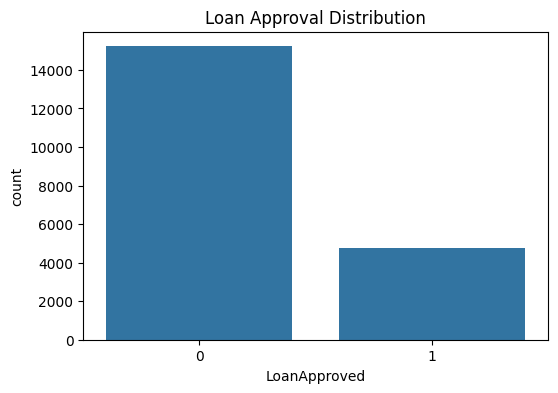

In [28]:
# 2(c).2 Univariate Analysis i - (Loan Approval Distribution)

plt.figure(figsize=(6,4))

sns.countplot(
    x='LoanApproved',
    data=loan_dataset
)

plt.title("Loan Approval Distribution")

plt.show()

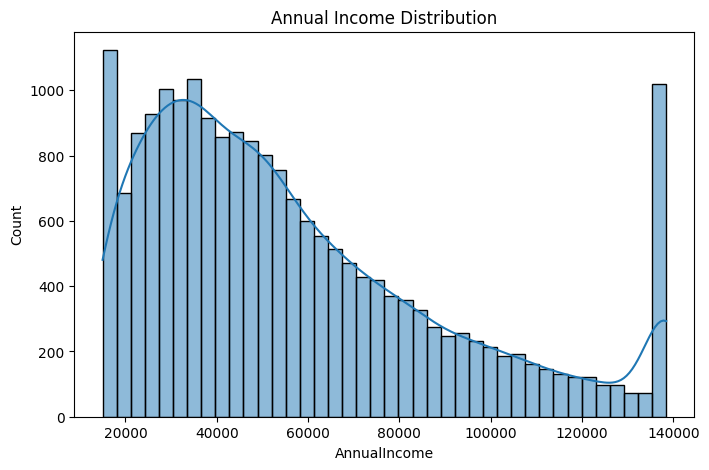

In [29]:
# 2(c).3 Univariate Analysis ii - (Income Distribution)

plt.figure(figsize=(8,5))

sns.histplot(
    loan_dataset['AnnualIncome'],
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

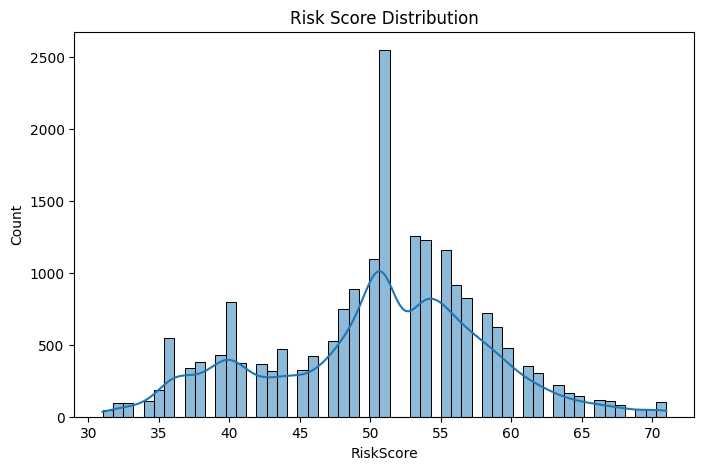

In [30]:
# 2(c).4 Univariate Analysis iii - (Risk Score Distribution)

plt.figure(figsize=(8,5))

sns.histplot(
    loan_dataset['RiskScore'],
    kde=True
)

plt.title("Risk Score Distribution")

plt.show()

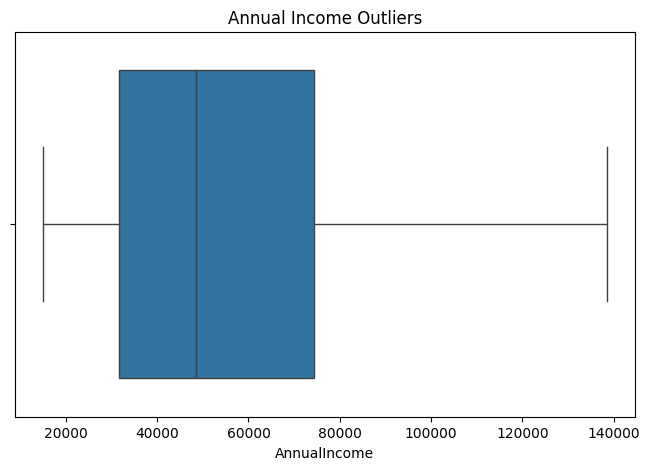

In [31]:
# 2(c).5 Univariate Analysis iv - (Boxplot)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=loan_dataset['AnnualIncome']
)

plt.title("Annual Income Outliers")

plt.show()

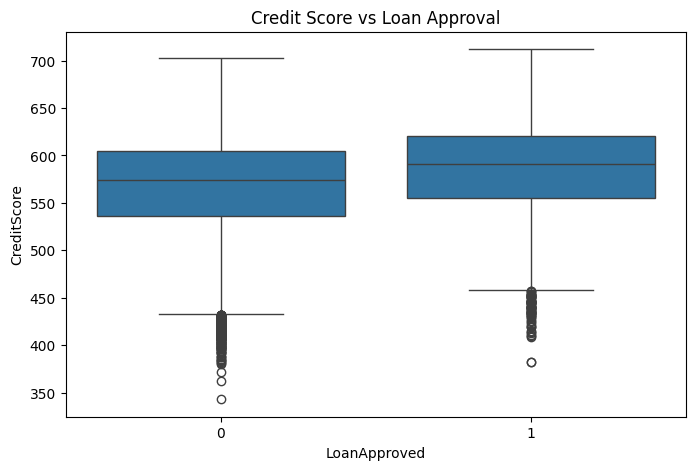

In [32]:
# 2(c).6 Bivariate Analysis i - (Credit Score vs Approval)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='LoanApproved',
    y='CreditScore',
    data=loan_dataset
)

plt.title(
    "Credit Score vs Loan Approval"
)

plt.show()

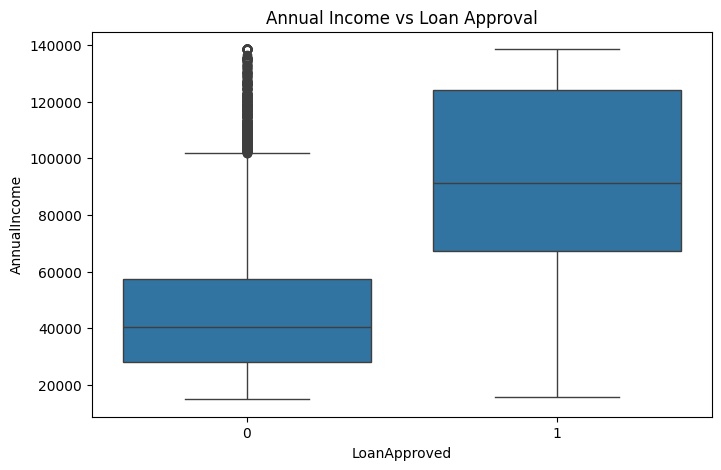

In [33]:
# 2(c).7 Bivariate Analysis ii - (Income vs Approval)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='LoanApproved',
    y='AnnualIncome',
    data=loan_dataset
)

plt.title(
    "Annual Income vs Loan Approval"
)

plt.show()

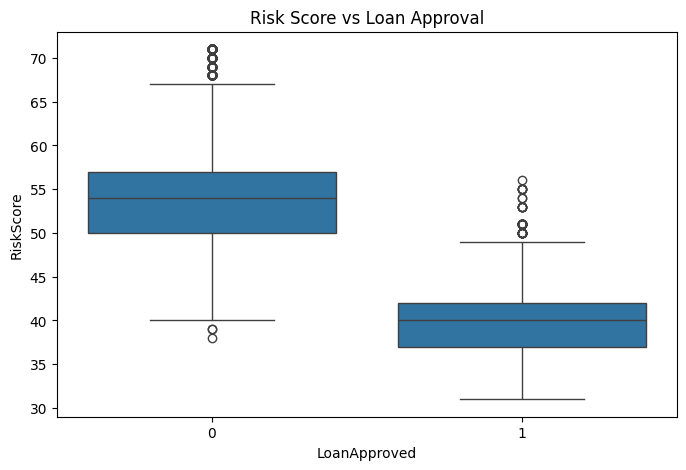

In [34]:
# 2(c).8 Bivariate Analysis iii - (Risk Score vs Approval)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='LoanApproved',
    y='RiskScore',
    data=loan_dataset
)

plt.title(
    "Risk Score vs Loan Approval"
)

plt.show()

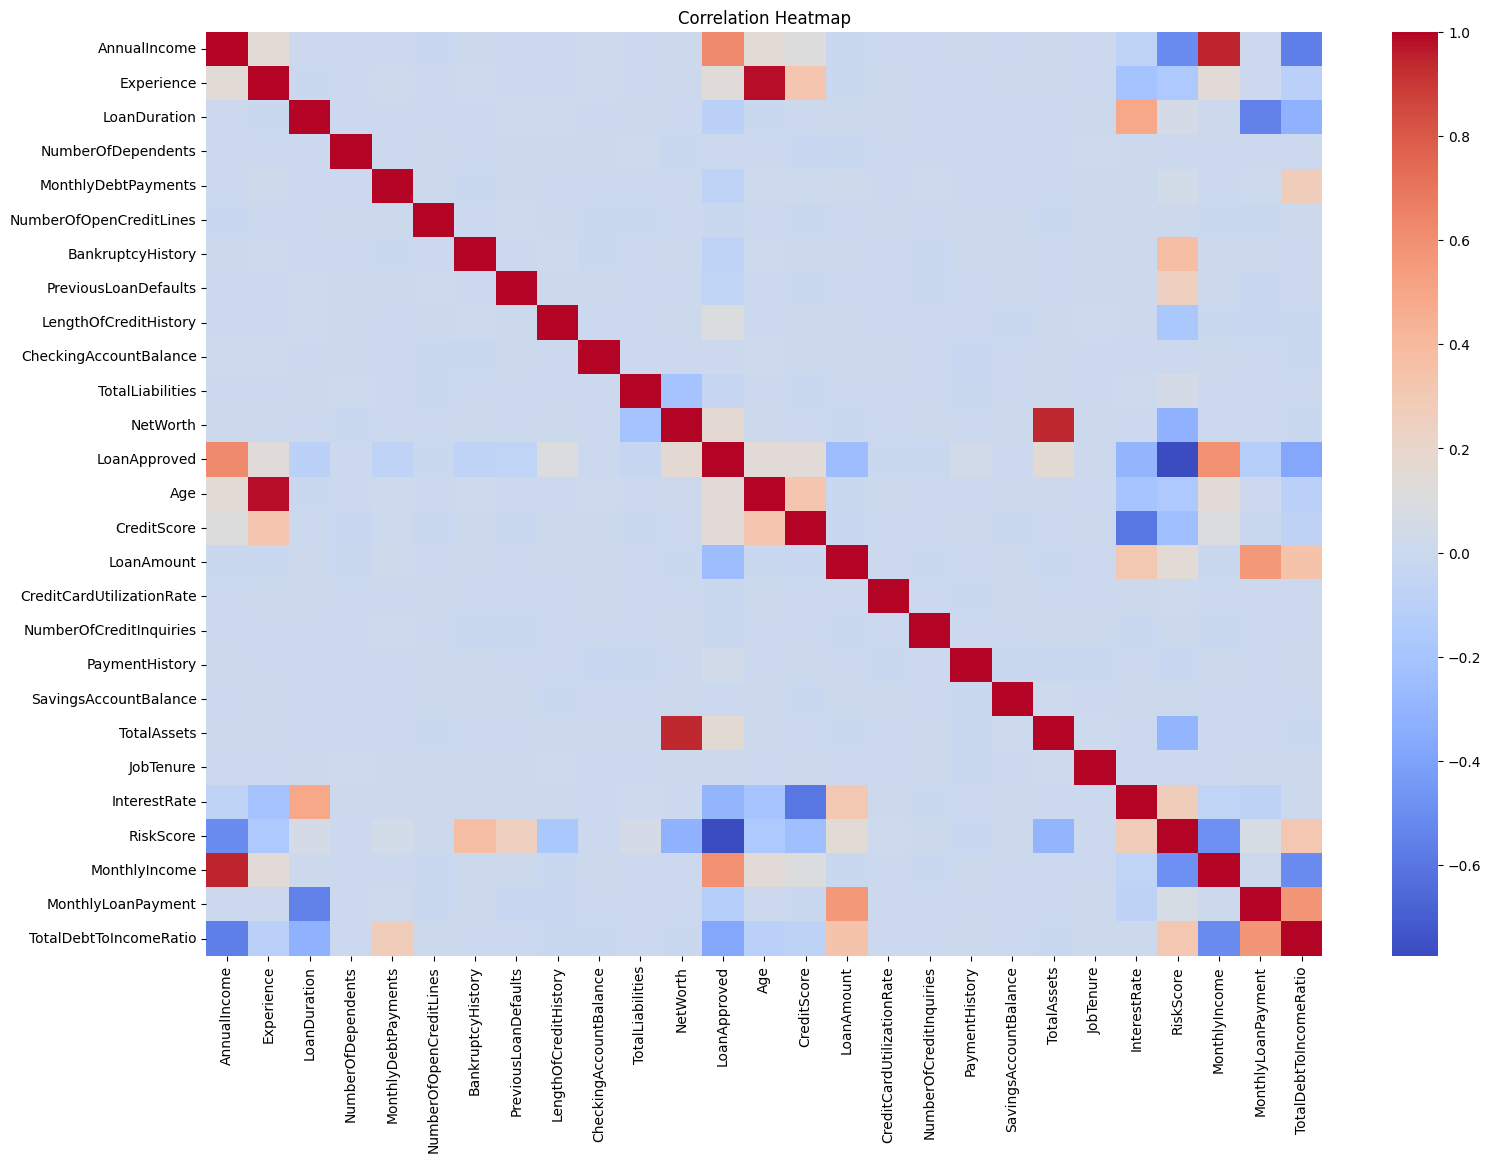

In [35]:
# 2(c).9 Multivariate Analysis i - Correlation Heatmap

numerical_cols = (
    loan_dataset
    .select_dtypes(
        include=['int64','float64']
    )
)

correlation = numerical_cols.corr()

plt.figure(
    figsize=(18,12)
)

sns.heatmap(
    correlation,
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

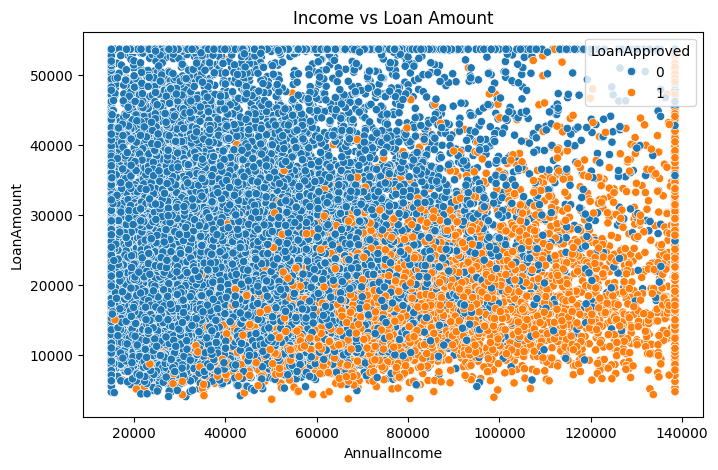

In [36]:
# 2(c).10 Multivariate Analysis ii - Scatter Plot

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='AnnualIncome',
    y='LoanAmount',
    hue='LoanApproved',
    data=loan_dataset
)

plt.title(
    "Income vs Loan Amount"
)

plt.show()

In [37]:
# 2(c).11 Final Dataset Save

loan_dataset.to_csv(
    "cleaned_loan_dataset.csv",
    index=False
)

# **Task 3(a) PCA for Sensitive Data Obfuscation**

In [38]:
# 3(a).1 Sensitive Financial Variables

sensitive_cols = [
    'AnnualIncome',
    'LoanAmount',
    'NetWorth',
    'SavingsAccountBalance',
    'TotalAssets'
]

In [39]:
# 3(a).2 Data Standardization Using StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale data
scaler = StandardScaler()

sensitive_scaled = scaler.fit_transform(
    loan_dataset[sensitive_cols]
)

In [40]:
# 3(a).3 PCA Transformation of Sensitive Data

pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    sensitive_scaled
)

pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1','PC2']
)

print(
    "Explained Variance Ratio:"
)

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.3888868  0.20145643]


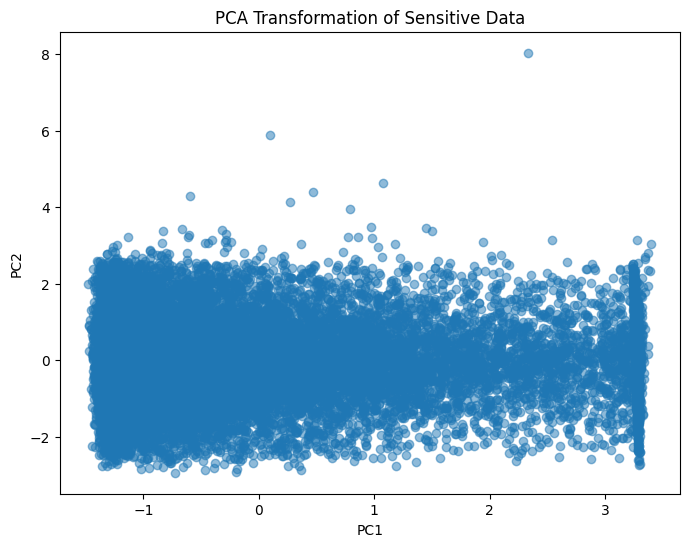

In [41]:
# 3(a).4 PCA Scatter Plot Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.5
)

plt.title(
    "PCA Transformation of Sensitive Data"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

# **Task 3(b) Data Preparation**

In [42]:
#Task 3(b).1 Encoding

loan_model = loan_dataset.drop(
    columns=[
        'ID',
        'ApplicationDate_demographic',
        'ApplicationDate_financial'
    ]
)

loan_model = pd.get_dummies(
    loan_model,
    drop_first=True
)

In [43]:
#Task 3(b).2 Features and Target

X = loan_model.drop(
    'LoanApproved',
    axis=1
)

y = loan_model['LoanApproved']

In [44]:
#Task 3(b).3 Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
#Task 3(b).4 Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# **Task 3(c) Supervised Machine Learning Models for Loan Approval**

========== Logistic Regression Results ==========
Accuracy          : 0.9952
Precision         : 0.9835
Recall            : 0.9969
F1 Score          : 0.9901
Training Accuracy : 0.9952
Testing Accuracy  : 0.9952


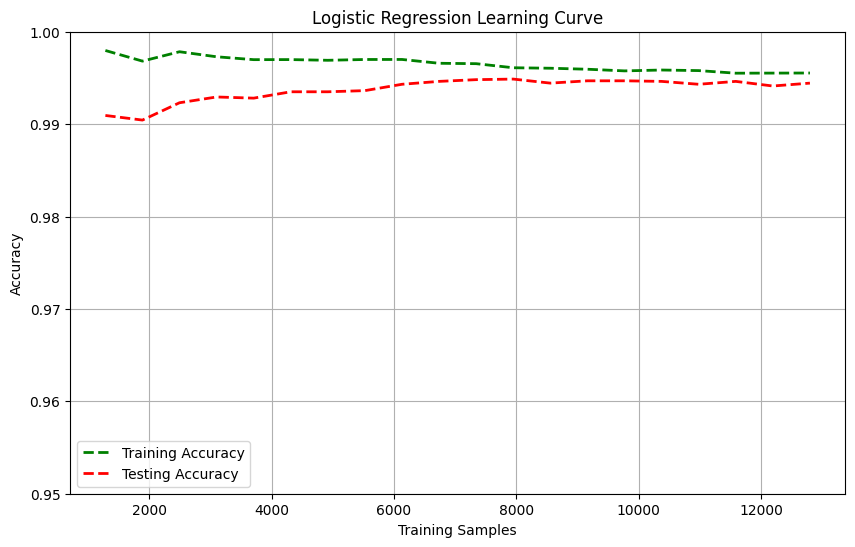

<Figure size 600x600 with 0 Axes>

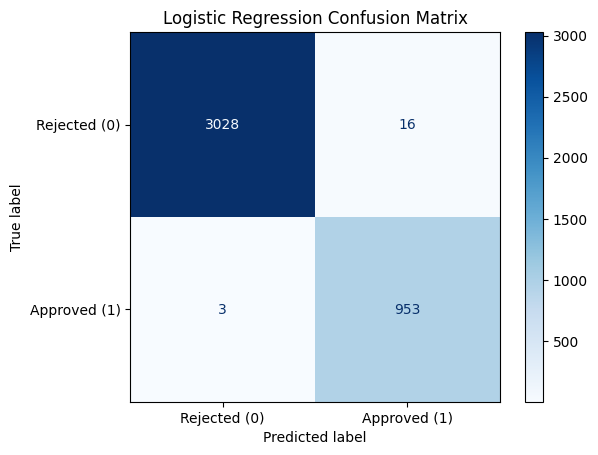

In [58]:
# Task 3(c).1 Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import learning_curve

import numpy as np
import matplotlib.pyplot as plt


# Create Model

log_model = LogisticRegression(
    max_iter=500,
    class_weight='balanced'
)

# Train Model

log_model.fit(
    X_train_scaled,
    y_train
)

# Predictions

y_pred_log = log_model.predict(
    X_test_scaled
)

y_train_pred = log_model.predict(
    X_train_scaled
)

# Performance Metrics

accuracy = accuracy_score(
    y_test,
    y_pred_log
)

precision = precision_score(
    y_test,
    y_pred_log
)

recall = recall_score(
    y_test,
    y_pred_log
)

f1 = f1_score(
    y_test,
    y_pred_log
)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

# Print Results

print("========== Logistic Regression Results ==========")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

# Learning Curve

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    estimator=log_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 20),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    'g--',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_mean,
    'r--',
    linewidth=2,
    label='Testing Accuracy'
)

plt.title('Logistic Regression Learning Curve')

plt.xlabel('Training Samples')
plt.ylabel('Accuracy')


plt.ylim(0.95, 1.0)

plt.legend()
plt.grid(True)

plt.show()

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected (0)', 'Approved (1)']
)

disp.plot(
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.show()

========== Random Forest Results ==========
Accuracy          : 0.9850
Precision         : 0.9638
Recall            : 0.9738
F1 Score          : 0.9688
Training Accuracy : 0.9955
Testing Accuracy  : 0.9850


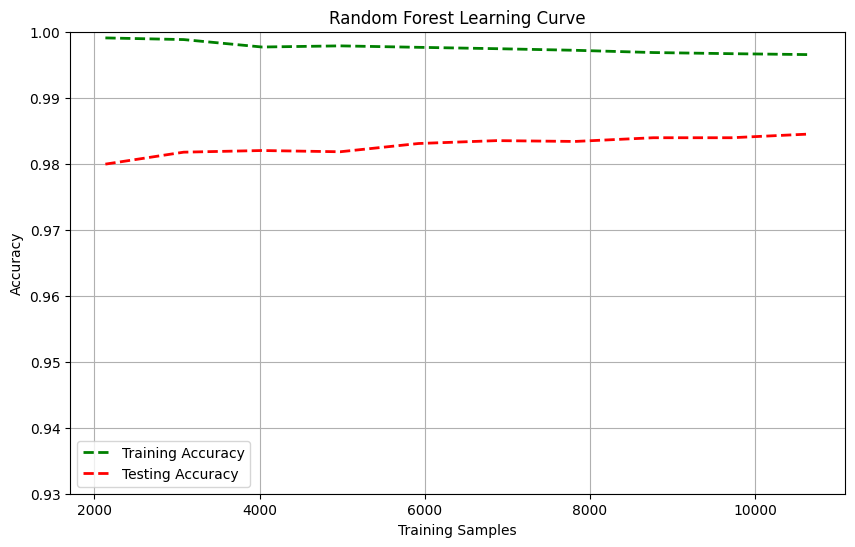

<Figure size 600x600 with 0 Axes>

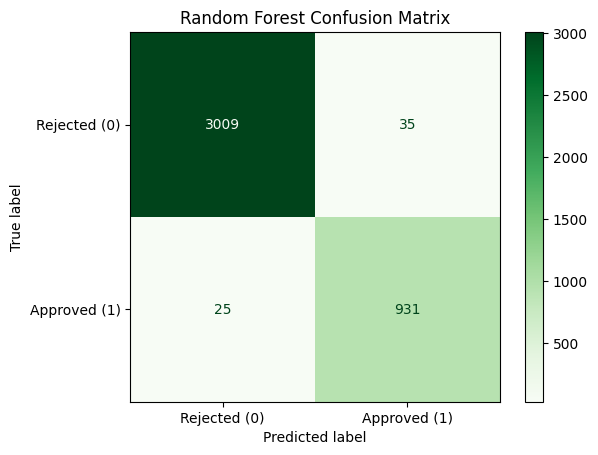

In [62]:
# Task 3(c).2 Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import learning_curve

import numpy as np
import matplotlib.pyplot as plt

# Create Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

# Train Model

rf_model.fit(
    X_train_scaled,
    y_train
)

# Predictions

y_pred_rf = rf_model.predict(
    X_test_scaled
)

y_train_pred_rf = rf_model.predict(
    X_train_scaled
)

# Performance Metrics

accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

precision = precision_score(
    y_test,
    y_pred_rf
)

recall = recall_score(
    y_test,
    y_pred_rf
)

f1 = f1_score(
    y_test,
    y_pred_rf
)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)

test_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

# Print Results

print("========== Random Forest Results ==========")

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

# Learning Curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf_model,
    X=X_train_scaled,
    y=y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    'g--',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_mean,
    'r--',
    linewidth=2,
    label='Testing Accuracy'
)

plt.title('Random Forest Learning Curve')

plt.xlabel('Training Samples')
plt.ylabel('Accuracy')

plt.ylim(0.93, 1.0)

plt.legend()
plt.grid(True)

plt.show()

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected (0)', 'Approved (1)']
)

disp.plot(
    cmap='Greens'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.show()

# **Task 3(d) Unsupervised Machine Learning Model for Customer Segmentation**

========== K-Means Clustering ==========
Number of Clusters : 3
Silhouette Score   : 0.3373

Cluster Distribution
Cluster
0    13241
1     5754
2     1005
Name: count, dtype: int64

Cluster Summary
         AnnualIncome  CreditScore  RiskScore  TotalLiabilities
Cluster                                                        
0        41351.340382   563.660826  54.339174      28319.979986
1        93551.678311   590.339242  41.565346      28280.567605
2        53606.119403   569.157214  53.010945     186404.989055


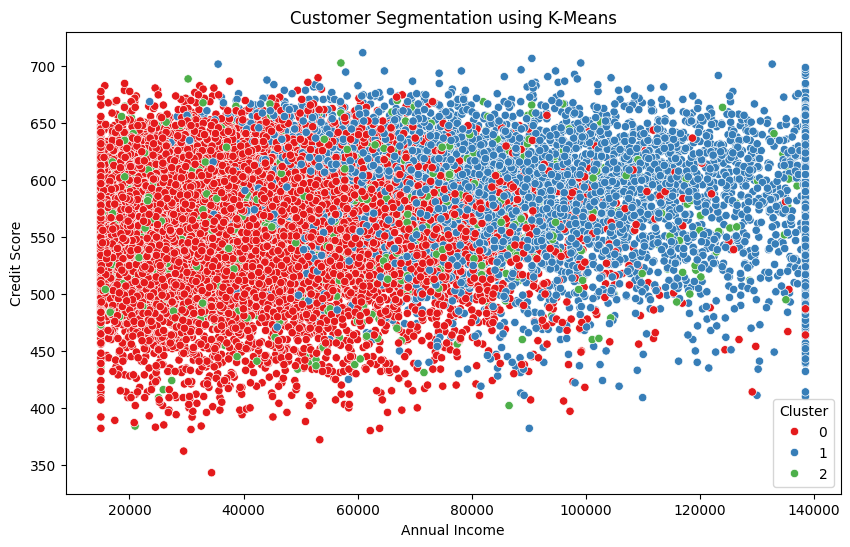

In [82]:
# =====================================================
# Task 3(c).5 K-Means Clustering
# Customer Segmentation
# =====================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# Select Features
# =====================================================

cluster_features = loan_model[
    [
        'AnnualIncome',
        'CreditScore',
        'RiskScore',
        'TotalLiabilities'
    ]
]

# =====================================================
# Feature Scaling
# =====================================================

scaler_cluster = StandardScaler()

cluster_scaled = scaler_cluster.fit_transform(
    cluster_features
)

# =====================================================
# K-Means Model
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    cluster_scaled
)

# =====================================================
# Add Cluster Labels
# =====================================================

loan_model['Cluster'] = clusters

# =====================================================
# Silhouette Score
# =====================================================

silhouette = silhouette_score(
    cluster_scaled,
    clusters
)

print("========== K-Means Clustering ==========")
print(f"Number of Clusters : 3")
print(f"Silhouette Score   : {silhouette:.4f}")

# =====================================================
# Cluster Counts
# =====================================================

print("\nCluster Distribution")

print(
    loan_model['Cluster'].value_counts()
)

# =====================================================
# Cluster Summary
# =====================================================

cluster_summary = loan_model.groupby(
    'Cluster'
)[
    [
        'AnnualIncome',
        'CreditScore',
        'RiskScore',
        'TotalLiabilities'
    ]
].mean()

print("\nCluster Summary")

print(cluster_summary)

# =====================================================
# Scatter Plot
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=loan_model,
    x='AnnualIncome',
    y='CreditScore',
    hue='Cluster',
    palette='Set1'
)

plt.title(
    'Customer Segmentation using K-Means'
)

plt.xlabel('Annual Income')
plt.ylabel('Credit Score')

plt.show()